# Foundations of Machine Learning: Support Vector Machines (SVM)

## Lecture Objectives
By the end of this module, you will be able to:
- Explain why SVM was developed compared to basic linear classifiers.
- Define a **Hyperplane** and describe its dimensions across feature spaces.
- Conceptualize **Maximum Margin** and identify **Support Vectors**.
- Understand how the mathematical sign of $w^T x + b$ determines the predicted class.

---

## 1. Why Do We Need Support Vector Machines?

Suppose we have the following linearly separable dataset:

* **Class A:** Sitting in the upper region.
* **Class B:** Sitting in the lower region.

Our goal is to draw a decision boundary to separate these two classes. A straight line can easily achieve this, but look at the variations below:

### Possible Hyperplane 1
```text
      ●   ●   ●
---------------------------- (Line runs very high)
      ×   ×   ×

●   ●   ●
            ------------------- (Line runs skewed)
      ×   ×   ×

●   ●   ●
------------------------------- (Line runs perfectly down the middle)
      ×   ×   ×

All three hyperplanes classify the training data with 100% accuracy.

---

#(Markdown: Definition & Dimensionality)**
```markdown
## 2. What is a Hyperplane?

A **Hyperplane** is the geometric decision boundary that separates different classes. Its dimensionality depends directly on the number of features (n) in your dataset:

| Number of Features | Hyperplane Geometry              |
| ------------------ | ---------------------------------|
| **1 Feature**      | A Point                          |
| **2 Features**     | A Straight Line                  |
| **3 Features**     | A 2D Plane                       | 
| **$n$ Features**   | An $n-1$ Dimensional  Hyperplane |

Even when a dataset has 8, 20, or 100 dimensions making it impossible for humans to visualize, the mathematical equations behave exactly like a simple line.

## 3. Mathematical Equation of a Hyperplane

In a 2D feature space, a line is traditionally represented as $w_1x_1 + w_2x_2 + b = 0$. In vector notation, this generalizes across any dimensional space as:

$$w^T x + b = 0$$

Where:
* $w$ is the **Weight Vector** (perpendicular to the separating hyperplane, dictating its orientation).
* $x$ is the **Feature Vector** (the input data coordinates).
* $b$ is the **Bias scalar** (shifting the hyperplane away from the origin).

### The Classification Rule
The geometric position of any data point relative to the hyperplane dictates the sign of the equation output:
* If $w^T x + b > 0$, the point sits on the **positive side** (Class $+1$, e.g., Blue).
* If $w^T x + b < 0$, the point sits on the **negative side** (Class $-1$, e.g., Red).

Therefore, the **sign** of the vector operation determines the final predicted class label.

## Deep Dive: Verifying Data Positions Relative to the Hyperplane

Now that we have the mathematical equation for our 2D line ($w^T x + b = 0$), let's see how a computer calculates which side of the line a data point falls on.

### The Mechanics of `np.dot(w, x)`
When we pass our weights $w = \begin{bmatrix} 3 & 2 \end{bmatrix}^T$ and a coordinate point $x = \begin{bmatrix} x_1 & x_2 \end{bmatrix}^T$ into `np.dot()`, the computer performs a row-by-column matrix multiplication:

$$w^T x + b = (w_1 \cdot x_1) + (w_2 \cdot x_2) + b$$

### Geometric Interpretation of the Output Score:
* **`raw_score > 0`**: The point sits in the positive half-space. The vector pointing from the line to this data point aligns with the direction of the weight vector $w$.
* **`raw_score < 0`**: The point sits in the negative half-space, opposing the direction of $w$.
* **`raw_score == 0`**: The point lies **exactly** on the decision boundary line itself.

In [ ]:
import numpy as np

def verify_hyperplane_side(w, x, b):
    """
    Computes the algebraic distance score to verify which side of the 
    hyperplane boundary a given feature coordinate vector belongs to.
    """
    # Perform the algebraic vector dot product: (w^T * x) + b
    raw_score = np.dot(w, x) + b
    
    # Core SVM binary decision classification rule based strictly on the sign
    predicted_class = "Blue (+1)" if raw_score > 0 else "Red (-1)"
    
    print(f"Feature Vector x: {x}")
    print(f"Computed Score (w^Tx + b): {raw_score:+.2f}")
    print(f"Assigned Side / Predicted Class: {predicted_class}\n")
    return raw_score

w_vector = np.array([3, 2])
bias = -8

print("--- Testing Point 1 ---")
x_point1 = np.array([4, 3])
score1 = verify_hyperplane_side(w_vector, x_point1, bias)

print("--- Testing Point 2 ---")
x_point2 = np.array([1, 2])
score2 = verify_hyperplane_side(w_vector, x_point2, bias)

--- Testing Point 1 ---
Feature Vector x: [4 3]
Computed Score (w^Tx + b): +10.00
Assigned Side / Predicted Class: Blue (+1)

--- Testing Point 2 ---
Feature Vector x: [1 2]
Computed Score (w^Tx + b): -1.00
Assigned Side / Predicted Class: Red (-1)



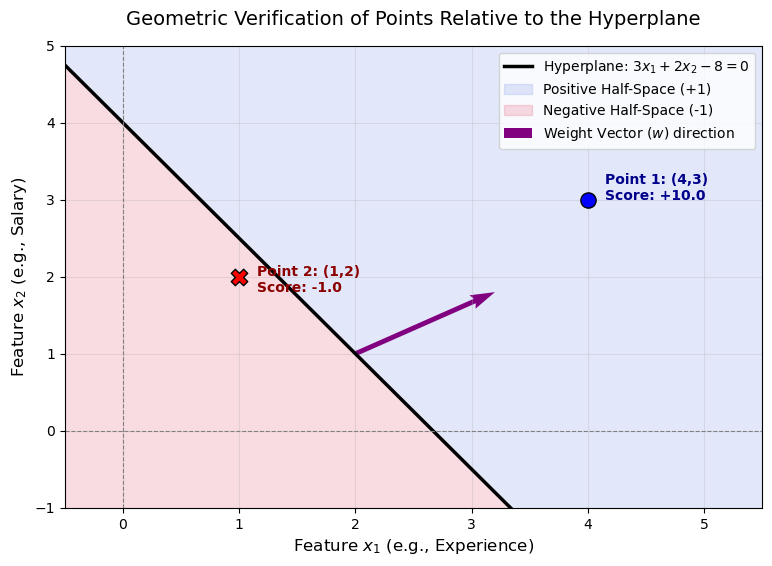

In [5]:
import matplotlib.pyplot as plt

# Create a coordinate space grid for plotting the line
x1_values = np.linspace(-1, 6, 200)

# Rearranging 3*x1 + 2*x2 - 8 = 0  -->  x2 = (-3*x1 + 8) / 2
x2_values = (-w_vector[0] * x1_values - bias) / w_vector[1]

# Set up the visualization plot space
plt.figure(figsize=(9, 6))

# Plot the optimal separating hyperplane line boundary
plt.plot(x1_values, x2_values, color='black', lw=2.5, label='Hyperplane: $3x_1 + 2x_2 - 8 = 0$')

# Fill the half-space regions with soft colors to show students the domains
plt.fill_between(x1_values, x2_values, 10, color='royalblue', alpha=0.15, label='Positive Half-Space (+1)')
plt.fill_between(x1_values, x2_values, -5, color='crimson', alpha=0.15, label='Negative Half-Space (-1)')

# Plot and annotate the textbook sample points
plt.scatter(x_point1[0], x_point1[1], color='blue', s=120, edgecolors='k', zorder=5)
plt.text(x_point1[0] + 0.15, x_point1[1], f'Point 1: (4,3)\nScore: {score1:+.1f}', color='darkblue', weight='bold')

plt.scatter(x_point2[0], x_point2[1], color='red', marker='X', s=140, edgecolors='k', zorder=5)
plt.text(x_point2[0] + 0.15, x_point2[1] - 0.2, f'Point 2: (1,2)\nScore: {score2:+.1f}', color='darkred', weight='bold')

# Plot the normal weight vector 'w' from the origin to show alignment direction
plt.quiver(2, 1, w_vector[0], w_vector[1], angles='xy', scale_units='xy', scale=2.5, 
           color='purple', width=0.007, label='Weight Vector ($w$) direction')

# Format plot constraints for clean class slide visibility
plt.xlim(-0.5, 5.5)
plt.ylim(-1, 5)
plt.axhline(0, color='gray', lw=0.8, ls='--')
plt.axvline(0, color='gray', lw=0.8, ls='--')
plt.xlabel('Feature $x_1$ (e.g., Experience)', fontsize=12)
plt.ylabel('Feature $x_2$ (e.g., Salary)', fontsize=12)
plt.title('Geometric Verification of Points Relative to the Hyperplane', fontsize=14, pad=15)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

## Part 4: How are $w$ and $b$ Actually Calculated?

To calculate the absolute best parameters for $w$ and $b$, SVM sets up two parallel boundary lines (bounding lanes) that pass through the closest data points of each class. These lines are called the **Margin Boundaries**.

We mathematically normalize the system so that these boundaries equal $+1$ and $-1$:
* **Positive Boundary Line:** $w^T x + b = 1$ (touches the closest Blue points)
* **Negative Boundary Line:** $w^T x + b = -1$ (touches the closest Red points)

### Deriving the Distance (The Margin Width)
Using vector geometry, the perpendicular distance from the origin to the positive hyperplane is $\frac{1 - b}{\|w\|}$, and to the negative hyperplane is $\frac{-1 - b}{\|w\|}$. 

The total distance between these two margins (the width of our safe lane) is the difference between them:

$$\text{Margin Width} = \frac{1 - b}{\|w\|} - \frac{-1 - b}{\|w\|} = \frac{2}{\|w\|}$$

To make this safe lane as wide as possible, we need to maximize $\frac{2}{\|w\|}$. Mathematically, maximizing a fraction means **minimizing its denominator ($\|w\|$)**.

### The Primal Optimization Formula

To remove the square root inside the vector norm calculation ($\|w\| = \sqrt{w_1^2 + w_2^2}$), we square the term. Our objective becomes a standard quadratic minimization problem:

$$\min_{w, b} \frac{1}{2} \|w\|^2$$

$$\text{Subject to the structural constraint: } y_i(w^T x_i + b) \ge 1 \quad \forall i \in \{1, \dots, n\}$$

Where:
* $y_i$ is the actual class label (**$+1$** for Blue, **$-1$** for Red).
* This constraint ensures **zero training errors**. Let's check why:
  * If a point is Blue ($y_i = +1$), then $(+1) \cdot (w^T x_i + b) \ge 1 \implies w^T x_i + b \ge 1$ (Correct Side!)
  * If a point is Red ($y_i = -1$), then $(-1) \cdot (w^T x_i + b) \ge 1 \implies w^T x_i + b \le -1$ (Correct Side!)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Step 1: Create a small, perfectly clean, toy dataset that we can easily trace
# Points: (1, 2) and (2, 3) belong to Class Red (-1)
# Points: (4, 1) and (5, 2) belong to Class Blue (+1)
X_toy = np.array([[1, 2], [2, 3], [4, 1], [5, 2]])
y_toy = np.array([-1, -1, 1, 1])

# Step 2: Initialize a Linear SVM with a large C value (forces Hard Margin)
# The internal optimization engine uses Quadratic Programming (QP) to compute w and b
svm_solver = SVC(kernel='linear', C=1000)
svm_solver.fit(X_toy, y_toy)

# Step 3: Extract the calculated parameters!
calculated_w = svm_solver.coef_[0]
calculated_b = svm_solver.intercept_[0]
support_vectors = svm_solver.support_vectors_

print("--- Optimization Solver Results ---")
print(f"Calculated Weight Vector w: {calculated_w}")
print(f"Calculated Bias b: {calculated_b:.4f}")
print(f"Identified Support Vectors coordinates:\n{support_vectors}")

--- Optimization Solver Results ---
Calculated Weight Vector w: [ 0.5 -0.5]
Calculated Bias b: -0.5000
Identified Support Vectors coordinates:
[[2. 3.]
 [4. 1.]]


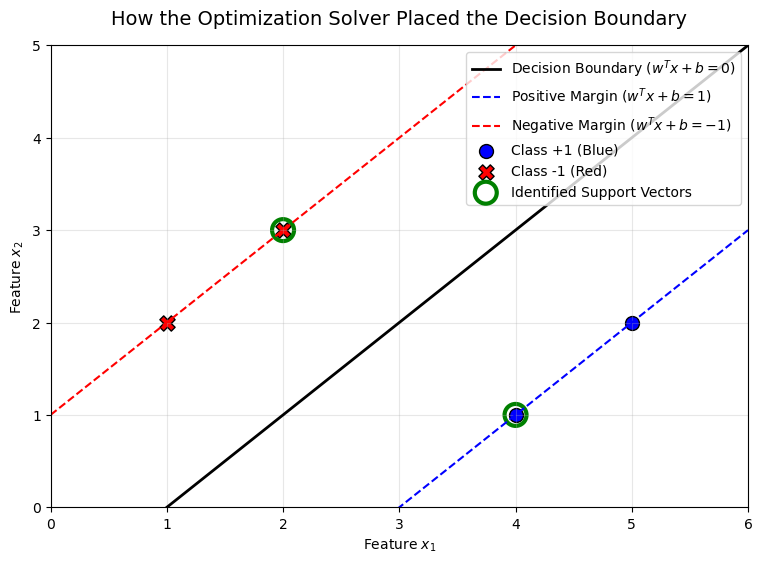

In [7]:
# Create coordinate space for displaying the calculated model boundaries
x1_space = np.linspace(0, 6, 100)

# Formula for central hyperplane: w0*x1 + w1*x2 + b = 0 -> x2 = (-w0*x1 - b) / w1
x2_hyperplane = (-calculated_w[0] * x1_space - calculated_b) / calculated_w[1]

# Formula for Positive Margin: w0*x1 + w1*x2 + b = 1 -> x2 = (1 - w0*x1 - b) / w1
x2_pos_margin = (1 - calculated_w[0] * x1_space - calculated_b) / calculated_w[1]

# Formula for Negative Margin: w0*x1 + w1*x2 + b = -1 -> x2 = (-1 - w0*x1 - b) / w1
x2_neg_margin = (-1 - calculated_w[0] * x1_space - calculated_b) / calculated_w[1]

plt.figure(figsize=(9, 6))

# Plot the calculated main decision boundary and margins
plt.plot(x1_space, x2_hyperplane, 'k-', lw=2, label='Decision Boundary ($w^Tx + b = 0$)')
plt.plot(x1_space, x2_pos_margin, 'b--', lw=1.5, label='Positive Margin ($w^Tx + b = 1$)')
plt.plot(x1_space, x2_neg_margin, 'r--', lw=1.5, label='Negative Margin ($w^Tx + b = -1$)')

# Plot the training data points
plt.scatter(X_toy[y_toy==1, 0], X_toy[y_toy==1, 1], color='blue', s=100, edgecolors='k', label='Class +1 (Blue)')
plt.scatter(X_toy[y_toy==-1, 0], X_toy[y_toy==-1, 1], color='red', marker='X', s=120, edgecolors='k', label='Class -1 (Red)')

# Highlight the specific data points chosen by the solver as Support Vectors
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=250, 
            facecolors='none', edgecolors='green', lw=3, label='Identified Support Vectors')

plt.xlim(0, 6)
plt.ylim(0, 5)
plt.xlabel('Feature $x_1$')
plt.ylabel('Feature $x_2$')
plt.title('How the Optimization Solver Placed the Decision Boundary', fontsize=14, pad=15)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

## Part 5: Case Study — Battery Management System (BMS) Fault Classifier

To make this completely practical, let's create a realistic dataset with explicit feature names. 

Imagine we are building a diagnostic classifier for an electric vehicle's Battery Management System. We track three features for each battery cell:
1. **Cell Voltage (V)**: Measured in Volts.
2. **Discharge Current (A)**: Measured in Amperes.
3. **Core Temperature (°C)**: Measured in degrees Celsius.

### The Problem
We want to classify cells into two categories:
* **Normal Operation (Label: $+1$)**: The cell is healthy and operating within safe tolerances.
* **Thermal Runway Hazard (Label: $-1$)**: The cell is drawing too much current, overheating, and dropping in voltage. This indicates a severe critical fault.

In [9]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC

# 1. Create a realistic dictionary containing our BMS telemetry features
bms_data = {
    'Cell_Voltage_V':    [4.12, 4.05, 3.98, 3.21, 3.10, 2.95],
    'Discharge_Current_A': [1.20, 2.50, 1.80, 8.50, 9.20, 12.0],
    'Core_Temp_C':         [28.5, 32.0, 30.1, 55.4, 62.1, 68.7],
    'Status_Label':        [1,    1,    1,   -1,   -1,   -1]  # 1 = Normal, -1 = Fault
}

# 2. Convert to a clean Pandas DataFrame for clear feature column visibility
df_bms = pd.DataFrame(bms_data)
print("--- Telemetry Dataframe Passed to the Model ---")
print(df_bms)

# 3. Extract features (X) and explicit target labels (y)
X_features = df_bms[['Cell_Voltage_V', 'Discharge_Current_A', 'Core_Temp_C']].values
y_labels = df_bms['Status_Label'].values

# 4. Initialize and fit the Support Vector Classifier
# We use a hard-margin configuration (high C) to force a clear boundary separation
bms_svc = SVC(kernel='linear', C=1000)
bms_svc.fit(X_features, y_labels)

# 5. Extract our calculated boundary values
w_final = bms_svc.coef_[0]
b_final = bms_svc.intercept_[0]
support_indices = bms_svc.support_

print("\n--- SVC Mathematical Solutions ---")
print(f"Calculated Weight Vector (w):")
print(f"  w1 (Voltage weight)    : {w_final[0]:.4f}")
print(f"  w2 (Current weight)    : {w_final[1]:.4f}")
print(f"  w3 (Temperature weight): {w_final[2]:.4f}")
print(f"Calculated System Bias (b): {b_final:.4f}")

--- Telemetry Dataframe Passed to the Model ---
   Cell_Voltage_V  Discharge_Current_A  Core_Temp_C  Status_Label
0            4.12                  1.2         28.5             1
1            4.05                  2.5         32.0             1
2            3.98                  1.8         30.1             1
3            3.21                  8.5         55.4            -1
4            3.10                  9.2         62.1            -1
5            2.95                 12.0         68.7            -1

--- SVC Mathematical Solutions ---
Calculated Weight Vector (w):
  w1 (Voltage weight)    : 0.0029
  w2 (Current weight)    : -0.0205
  w3 (Temperature weight): -0.0801
Calculated System Bias (b): 3.6029


# Support Vector Regression (SVR)

## 1. Moving from Classification to Regression
In classification, our goal was to find a decision boundary that keeps data points **out** of the margin. 
In **Support Vector Regression (SVR)**, the objective flips: we want to fit as many data points as possible **inside** a custom margin envelope surrounding our regression line.

This custom margin zone is called the **$\epsilon$-tube (Epsilon Tube)**.



### Core Structural Parameters:
* **$\epsilon$ (Epsilon):** Dictates the radius/width of the tube. Any data point that falls *inside* this tube experiences **zero loss**. We tolerate its variance completely.
* **Slack Variables ($\xi_i, \xi_i^*$):** If a noisy data point escapes outside the tube boundaries, it incurs a penalty. 
  * $\xi_i$ measures the error distance for points sitting *above* the tube.
  * $\xi_i^*$ measures the error distance for points sitting *below* the tube.

### The Optimization Framework
$$\min_{w, b} \frac{1}{2} \|w\|^2 + C \sum_{i=1}^n (\xi_i + \xi_i^*)$$

$$\text{Subject to: } \begin{cases} y_i - (w^T x_i + b) \le \epsilon + \xi_i \\ (w^T x_i + b) - y_i \le \epsilon + \xi_i^* \\ \xi_i, \xi_i^* \ge 0 \end{cases}$$

The parameter **$C$** acts as our trade-off balance: a very high $C$ heavily penalizes points that escape the tube, forcing the regression line to track outliers tightly.

## Part 2: Case Study — Predictive State of Health (SoH) Modeling

Let's create a realistic continuous engineering dataset with explicit feature names to show your students how SVR is deployed.

Imagine we are monitoring a battery cell over hours of operation. We want to predict the continuous **Cell Internal Resistance ($m\Omega$)** based strictly on its **Operating Core Temperature (°C)**. 
* As the temperature climbs abnormally high or drops too low, internal chemical degradation accelerates, causing resistance to spike non-linearly.

In [11]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR

# 1. Generate realistic engineering telemetry (Non-linear parabolic resistance curve)
np.random.seed(42)
temp_inputs = np.linspace(15, 65, 40)
# Resistance spikes at extremes: R = 0.01*(T-35)^2 + 12 + noise
resistance_targets = 0.01 * (temp_inputs - 35)**2 + 12 + np.random.normal(0, 0.4, temp_inputs.shape[0])

# 2. Package into a clean DataFrame for feature transparency
df_bms_reg = pd.DataFrame({
    'Core_Temperature_C': temp_inputs,
    'Internal_Resistance_mOhm': resistance_targets
})

print("--- Telemetry Regression Dataframe ---")
print(df_bms_reg.head(10))

# 3. Shape features for Scikit-Learn compliance (X must be 2D array)
X_reg = df_bms_reg[['Core_Temperature_C']].values
y_reg = df_bms_reg['Internal_Resistance_mOhm'].values

# 4. Initialize and fit the SVR model
# We use the RBF (Radial Basis Function) kernel to gracefully capture the parabolic curve
# epsilon=0.5 means any data point within 0.5 mOhm of our line generates ZERO error penalty
svr_bms = SVR(kernel='rbf', C=50, epsilon=0.5, gamma=0.01)
svr_bms.fit(X_reg, y_reg)

print("\n--- SVR Training Status ---")
print(f"Model successfully optimized using RBF Kernel.")
print(f"Configured Epsilon (Tube Radius): {svr_bms.epsilon} mOhm")
print(f"Number of Support Vectors chosen: {len(svr_bms.support_)}")

--- Telemetry Regression Dataframe ---
   Core_Temperature_C  Internal_Resistance_mOhm
0           15.000000                 16.198686
1           16.282051                 15.448310
2           17.564103                 15.299181
3           18.846154                 15.218679
4           20.128205                 14.118041
5           21.410256                 13.753157
6           22.692308                 14.146478
7           23.974359                 13.522621
8           25.256410                 12.761586
9           26.538462                 12.933000

--- SVR Training Status ---
Model successfully optimized using RBF Kernel.
Configured Epsilon (Tube Radius): 0.5 mOhm
Number of Support Vectors chosen: 10


In [17]:
new_temp = np.array([[40]])

predicted_resistance = svr_bms.predict(new_temp)

print(f"Temperature : {new_temp[0][0]} °C")
print(f"Predicted Resistance : {predicted_resistance[0]:.2f} mΩ")

Temperature : 40 °C
Predicted Resistance : 12.22 mΩ


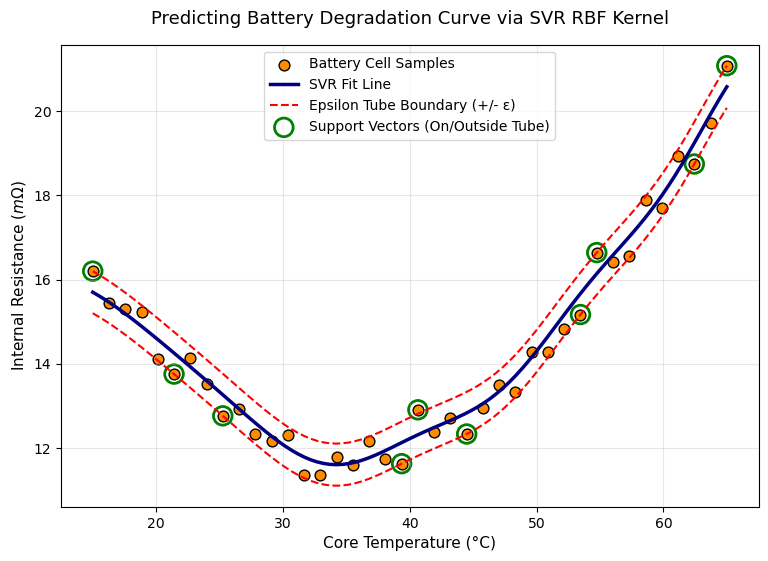

In [12]:
import matplotlib.pyplot as plt

# Generate a smooth prediction line array space
temp_test_space = np.linspace(15, 65, 100).reshape(-1, 1)
predicted_resistance = svr_bms.predict(temp_test_space)

plt.figure(figsize=(9, 6))

# Plot raw telemetry data points
plt.scatter(df_bms_reg['Core_Temperature_C'], df_bms_reg['Internal_Resistance_mOhm'], 
            color='darkorange', edgecolor='k', s=60, label='Battery Cell Samples')

# Plot central SVR continuous prediction curve line
plt.plot(temp_test_space, predicted_resistance, color='navy', lw=2.5, label='SVR Fit Line')

# Draw the boundary lines of the Epsilon-Tube margin envelope
plt.plot(temp_test_space, predicted_resistance + svr_bms.epsilon, 'r--', lw=1.5, label='Epsilon Tube Boundary (+/- ε)')
plt.plot(temp_test_space, predicted_resistance - svr_bms.epsilon, 'r--')

# Highlight the explicit Support Vector data points selected by the solver
sv_x = X_reg[svr_bms.support_]
sv_y = y_reg[svr_bms.support_]
plt.scatter(sv_x, sv_y, s=180, facecolors='none', edgecolors='green', lw=2, label='Support Vectors (On/Outside Tube)')

# Layout configuration
plt.xlabel('Core Temperature (°C)', fontsize=11)
plt.ylabel('Internal Resistance ($m\Omega$)', fontsize=11)
plt.title('Predicting Battery Degradation Curve via SVR RBF Kernel', fontsize=13, pad=15)
plt.legend(loc='upper center')
plt.grid(True, alpha=0.3)
plt.show()

## Part 7: Non-Linear SVC using the Kernel Trick

What happens if our classification boundary isn't a flat plane or a straight line? 

If our data is arranged in complex, overlapping shapes, a linear boundary will fail completely. We use the **Kernel Trick** to map our features into a higher-dimensional space where a flat boundary can cleanly separate them—without the massive computational cost of calculating the new coordinates manually.

Let's look at the **Gaussian RBF (Radial Basis Function)** Kernel:
$$K(x, y) = \exp\left(-\gamma \|x - y\|^2\right)$$

Think of the RBF Kernel as a "proximity sensor." It draws circular, flexible boundaries around clusters of data points.

## Part 8: End-to-End Practical Workflow — Industrial Motor Predictive Maintenance

In this section, we will train a Support Vector Classifier on an authentic industrial engineering telemetry matrix. 

### The Engineering Scenario:
We are monitoring high-power 3-phase induction motors running mission-critical machinery. We sample data from four installed physical sensors:
1. **Vibration Amplitude (mm/s):** High spikes indicate axis misalignment or broken internal bearings.
2. **Stator Temperature (°C):** Overheating indicates winding insulation breakdown or excessive load.
3. **Acoustic emission (dB):** High-frequency ultrasonic sound indicates micro-fractures.
4. **Current Inbalance (A):** Imbalances between electrical phases indicate electrical breakdown.

### The Objective:
Build an automated real-time diagnostics system running on our edge processor to categorize motor states into:
* `0`: **Bearing Wear Fault** (Requires urgent maintenance isolation)
* `1`: **Normal Safe Operation**

In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Generate an authentic, realistic sensor pool dataset (150 industrial motors)
np.random.seed(42)
n_samples = 150

# Group A: Normal Motors (Low vibration, safe temperatures, quiet, balanced current)
normal_vibration   = np.random.normal(loc=1.5, scale=0.4, size=n_samples//2)
normal_temp        = np.random.normal(loc=45.0, scale=4.0, size=n_samples//2)
normal_acoustic    = np.random.normal(loc=35.0, scale=3.0, size=n_samples//2)
normal_current     = np.random.normal(loc=0.2, scale=0.05, size=n_samples//2)
normal_labels      = np.ones(n_samples//2, dtype=int) # Class 1

# Group B: Faulty Motors (High vibration, elevated temperature, louder sound, erratic current)
fault_vibration    = np.random.normal(loc=5.8, scale=1.2, size=n_samples//2)
fault_temp         = np.random.normal(loc=78.0, scale=8.0, size=n_samples//2)
fault_acoustic     = np.random.normal(loc=65.0, scale=6.0, size=n_samples//2)
fault_current      = np.random.normal(loc=1.4, scale=0.3, size=n_samples//2)
fault_labels       = np.zeros(n_samples//2, dtype=int) # Class 0

# 2. Package data vectors into a unified Pandas structural DataFrame
motor_dataframe = pd.DataFrame({
    'Vibration_mm_s':       np.concatenate([normal_vibration, fault_vibration]),
    'Stator_Temp_C':        np.concatenate([normal_temp, fault_temp]),
    'Acoustic_Noise_dB':    np.concatenate([normal_acoustic, fault_acoustic]),
    'Current_Imbalance_A':  np.concatenate([normal_current, fault_current]),
    'Maintenance_Status':   np.concatenate([normal_labels, fault_labels])
})

# Shuffle the dataframe rows uniformly to simulate real incoming stream
motor_dataframe = motor_dataframe.sample(frac=1, random_state=42).reset_index(drop=True)

print("--- Telemetry Log Preview (First 5 Rows) ---")
print(motor_dataframe.head())

# 3. Separate features arrays from classification target variables
X_motor = motor_dataframe[['Vibration_mm_s', 'Stator_Temp_C', 'Acoustic_Noise_dB', 'Current_Imbalance_A']].values
y_motor = motor_dataframe['Maintenance_Status'].values

# 4. Standard train/test partition split (80% train / 20% validation)
X_train, X_test, y_train, y_test = train_test_split(X_motor, y_motor, test_size=0.2, random_state=42)

# 5. Apply standard normalization to balance scalar dimensions
scaler_motor = StandardScaler()
X_train_scaled = scaler_motor.fit_transform(X_train)
X_test_scaled = scaler_motor.transform(X_test)

--- Telemetry Log Preview (First 5 Rows) ---
   Vibration_mm_s  Stator_Temp_C  Acoustic_Noise_dB  Current_Imbalance_A  \
0        2.125857      47.087766          30.161852             0.240643   
1        1.136790      43.689351          34.263836             0.243288   
2        5.191668      87.434377          59.832295             0.838762   
3        6.532444      95.518423          68.024279             1.477917   
4        5.127783      84.978565          70.730854             0.911737   

   Maintenance_Status  
0                   1  
1                   1  
2                   0  
3                   0  
4                   0  


In [15]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Initialize an SVC model using the non-linear Gaussian RBF Kernel
# We use an RBF kernel to handle multi-sensor boundary intersections natively
motor_svc_model = SVC(kernel='rbf', C=5.0, gamma='scale')
motor_svc_model.fit(X_train_scaled, y_train)

# 2. Extract classification outputs from the test pool
y_pred_motor = motor_svc_model.predict(X_test_scaled)

# 3. Print out diagnostic performance tables
print("--- Diagnostic Evaluation Metrics ---")
print(f"Edge Classifier Accuracy: {accuracy_score(y_test, y_pred_motor)*100:.2f}%\n")

print("--- Confusion Matrix Layout ---")
print(confusion_matrix(y_test, y_pred_motor))

print("\n--- Detailed Classification Performance Profile ---")
print(classification_report(y_test, y_pred_motor, target_names=['Mechanical Fault', 'Normal Runtime']))

print(f"Total Support Vector vectors saved in memory: {len(motor_svc_model.support_)}")

--- Diagnostic Evaluation Metrics ---
Edge Classifier Accuracy: 100.00%

--- Confusion Matrix Layout ---
[[13  0]
 [ 0 17]]

--- Detailed Classification Performance Profile ---
                  precision    recall  f1-score   support

Mechanical Fault       1.00      1.00      1.00        13
  Normal Runtime       1.00      1.00      1.00        17

        accuracy                           1.00        30
       macro avg       1.00      1.00      1.00        30
    weighted avg       1.00      1.00      1.00        30

Total Support Vector vectors saved in memory: 9
